In [26]:
# 1. Importing Libraries
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split

# Downloading required NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

# 2. Loading Data
df = pd.read_csv('data/raw/spam.csv', encoding='latin-1')
df = df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
df = df.rename(columns={'v1': 'label', 'v2': 'message'})

# 3. Hand-crafted Features (إضافة ممتازة منك)
df['msg_len']     = df['message'].apply(len)
df['num_upper']   = df['message'].apply(lambda x: sum(1 for c in x if c.isupper()))
df['num_digits']  = df['message'].apply(lambda x: sum(1 for c in x if c.isdigit()))
df['num_exclaim'] = df['message'].apply(lambda x: x.count('!'))

# 4. Text Cleaning Function
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    cleaned_tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    return ' '.join(cleaned_tokens)

print("Cleaning text... (This might take a few seconds)")
df['cleaned_message'] = df['message'].apply(clean_text)

# 5. Label Encoding
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

# 6. Train-Test Split (بدون TF-IDF هنا عشان نمنع تسريب البيانات)
# هنختار الأعمدة اللي هندخلها الموديل (النص المنظف + الأرقام اللي إنت ضفتها)
features = ['cleaned_message', 'msg_len', 'num_upper', 'num_digits', 'num_exclaim']
X = df[features]
y = df['label_num']

# تقسيم الداتا
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("\nPreprocessing Done!")
print(f"Training shape : {X_train.shape}")
print(f"Test shape     : {X_test.shape}")

Cleaning text... (This might take a few seconds)

Preprocessing Done!
Training shape : (4457, 5)
Test shape     : (1115, 5)


In [27]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

# 1. تحديد أنواع الأعمدة (اللي طالعة من Cell 1)
text_feature = 'cleaned_message'
numeric_features = ['msg_len', 'num_upper', 'num_digits', 'num_exclaim']

# 2. بناء معالج الأعمدة (ColumnTransformer) زي ما الملف طالب
# ده هيعمل TF-IDF للنص، وهيعمل MinMax scaling للأرقام
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=5000), text_feature),
        ('num', MinMaxScaler(), numeric_features)
    ]
)

# 3. تعريف الموديلز المطلوبة (متطابقة مع المشروع الخامس)
models = {
    "Logistic Regression (Primary)": LogisticRegression(random_state=42, max_iter=1000),
    "Multinomial Naive Bayes":        MultinomialNB(),
    "Linear SVM":                     LinearSVC(random_state=42),
    "Decision Tree":                  DecisionTreeClassifier(random_state=42, max_depth=10),
    "Random Forest":                  RandomForestClassifier(random_state=42, n_estimators=100)
}

# 4. إعداد الـ Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Baseline Models CV F1-Scores (Mean ± Std):\n" + "-"*40)

# 5. التقييم باستخدام الـ Pipeline الكامل
for name, model in models.items():
    # ربط المعالجة بالموديل في Pipeline واحد عشان نمنع تسريب البيانات
    pipe = Pipeline([
        ('prep', preprocessor),
        ('classifier', model)
    ])
    
    # التقييم الآمن والموثوق
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    print(f"{name}: {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%")

print("-"*40)

Baseline Models CV F1-Scores (Mean ± Std):
----------------------------------------
Logistic Regression (Primary): 90.02% ± 1.32%
Multinomial Naive Bayes: 89.99% ± 0.68%
Linear SVM: 95.24% ± 1.09%
Decision Tree: 92.23% ± 1.63%
Random Forest: 94.35% ± 0.78%
----------------------------------------


In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

# ════════════════════════════════════════
# 1. Logistic Regression Tuning
# ════════════════════════════════════════
print("Tuning Logistic Regression...\n" + "-"*40)

# بنبني الـ Pipeline اللي بيجمع المعالجة (من الخلية اللي فاتت) مع الموديل
pipe_lr = Pipeline([
    ('prep', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# بنزود classifier__ عشان الـ GridSearch يعرف إنه بيعدل في جزء الموديل
param_grid_lr = {
    'classifier__C':       [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver':  ['liblinear']
}

grid_lr = GridSearchCV(
    pipe_lr, 
    param_grid_lr, 
    cv=cv, scoring='f1', n_jobs=-1
)
# دلوقتي نقدر نعمل fit بأمان على X_train لأن الـ Pipeline هيعالج النصوص والأرقام
grid_lr.fit(X_train, y_train)

print("Best Params :", grid_lr.best_params_)
print(f"Best CV F1  : {grid_lr.best_score_ * 100:.2f}%")
print("-"*40)

# ════════════════════════════════════════
# 2. Naive Bayes Tuning
# ════════════════════════════════════════
print("\nTuning Naive Bayes...\n" + "-"*40)

pipe_nb = Pipeline([
    ('prep', preprocessor),
    ('classifier', MultinomialNB())
])

param_grid_nb = {'classifier__alpha': [0.1, 0.5, 1.0]}

grid_nb = GridSearchCV(
    pipe_nb, 
    param_grid_nb, 
    cv=cv, scoring='f1', n_jobs=-1
)
grid_nb.fit(X_train, y_train)

print("Best Params :", grid_nb.best_params_)
print(f"Best CV F1  : {grid_nb.best_score_ * 100:.2f}%")
print("-"*40)

# ════════════════════════════════════════
# 3. Linear SVM Tuning
# ════════════════════════════════════════
print("\nTuning Linear SVM...\n" + "-"*40)

pipe_svm = Pipeline([
    ('prep', preprocessor),
    ('classifier', LinearSVC(random_state=42, max_iter=2000))
])

param_grid_svm = {'classifier__C': [0.1, 1, 10]}

grid_svm = GridSearchCV(
    pipe_svm, 
    param_grid_svm, 
    cv=cv, scoring='f1', n_jobs=-1
)
grid_svm.fit(X_train, y_train)

print("Best Params :", grid_svm.best_params_)
print(f"Best CV F1  : {grid_svm.best_score_ * 100:.2f}%")
print("-"*40)

# ════════════════════════════════════════
# 4. ملخص المقارنة وحفظ الأفضل
# ════════════════════════════════════════
print("\nFinal Tuning Summary:")
print(f"  Logistic Regression : {grid_lr.best_score_*100:.2f}%")
print(f"  Naive Bayes         : {grid_nb.best_score_*100:.2f}%")
print(f"  Linear SVM          : {grid_svm.best_score_*100:.2f}%")
print("-"*40)

# حفظ الـ Pipeline الكامل الأفضل (شامل المعالجة والموديل) للـ Evaluation
best_pipeline = grid_lr.best_estimator_ 
print("\nBest Pipeline saved for evaluation (Logistic Regression)")

Tuning Logistic Regression...
----------------------------------------
Best Params : {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Best CV F1  : 94.86%
----------------------------------------

Tuning Naive Bayes...
----------------------------------------
Best Params : {'classifier__alpha': 0.1}
Best CV F1  : 94.25%
----------------------------------------

Tuning Linear SVM...
----------------------------------------
Best Params : {'classifier__C': 1}
Best CV F1  : 95.24%
----------------------------------------

Final Tuning Summary:
  Logistic Regression : 94.86%
  Naive Bayes         : 94.25%
  Linear SVM          : 95.24%
----------------------------------------

Best Pipeline saved for evaluation (Logistic Regression)


Evaluating Best Pipeline on Test Set...
----------------------------------------
              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       966
        Spam       1.00      0.91      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115

PR-AUC: 0.9796
----------------------------------------


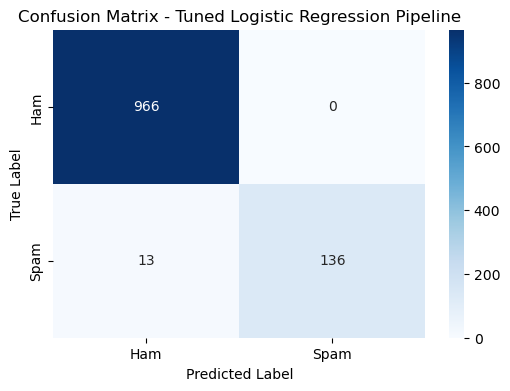

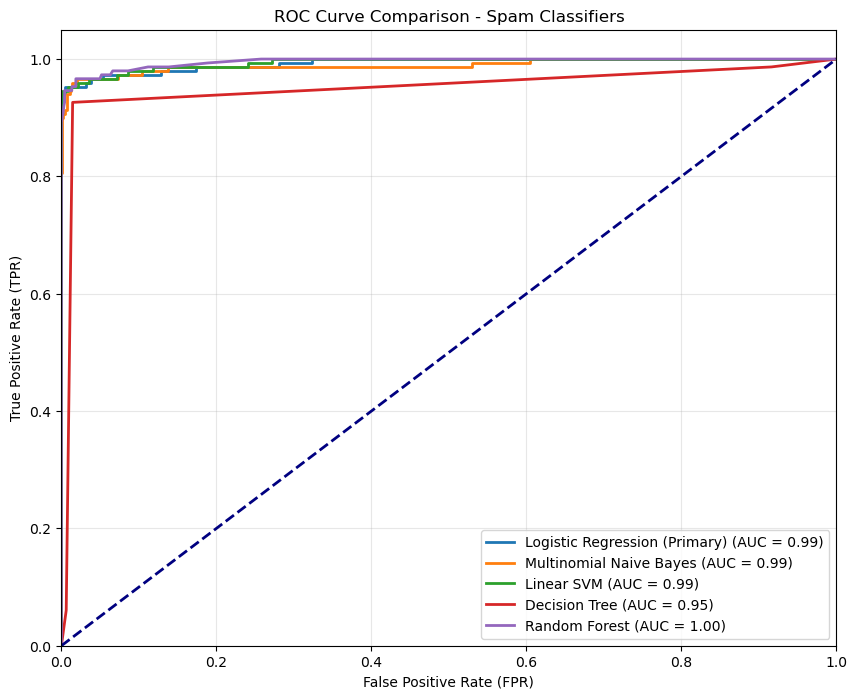

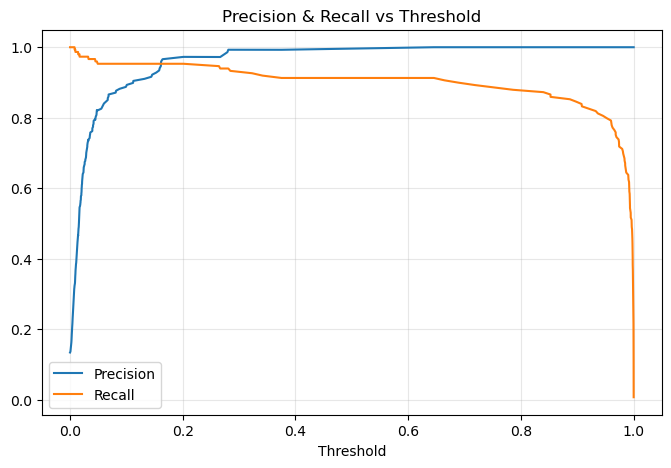

----------------------------------------


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, average_precision_score, precision_recall_curve)
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

print("Evaluating Best Pipeline on Test Set...\n" + "-"*40)

# 1. Classification Report (باستخدام best_pipeline اللي طلع من الخلية اللي فاتت)
y_pred_best = best_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_best, target_names=['Ham', 'Spam']))

# 2. PR-AUC
# برضه بنستخدم best_pipeline
pr_auc = average_precision_score(y_test, best_pipeline.predict_proba(X_test)[:,1])
print(f'PR-AUC: {pr_auc:.4f}')
print("-"*40)

# 3. Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix - Tuned Logistic Regression Pipeline')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 4. ROC Curve — كل الموديلز على نفس الـ plot
plt.figure(figsize=(10, 8))

# تجميع كل الموديلز.. الموديلز المتعملها Tune جاهزة، والباقي هنحطه في Pipeline
trained_models = {
    "Logistic Regression (Primary)": best_pipeline,
    "Multinomial Naive Bayes":        grid_nb.best_estimator_,
    "Linear SVM":                     grid_svm.best_estimator_,
    # لازم نحط دول في بايبلاين عشان X_train و X_test بقوا ميكس نصوص وأرقام
    "Decision Tree":                  Pipeline([('prep', preprocessor), ('classifier', DecisionTreeClassifier(random_state=42, max_depth=10))]),
    "Random Forest":                  Pipeline([('prep', preprocessor), ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))]),
}

# تدريب الموديلات اللي لسه متدربتش (DT و RF)
for name in ["Decision Tree", "Random Forest"]:
    trained_models[name].fit(X_train, y_train)

# رسم الـ ROC Curve
for name, model in trained_models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        continue

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve Comparison - Spam Classifiers')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 5. Threshold Analysis
probs = best_pipeline.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, probs)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1],    label='Recall')
plt.xlabel('Threshold')
plt.title('Precision & Recall vs Threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("-"*40)

In [30]:
import joblib

# Saving the complete pipeline (TF-IDF + Tuned Model) into one file
joblib.dump(best_pipeline, 'best_spam_pipeline.pkl')

print("Pipeline saved successfully! 🎉")

Pipeline saved successfully! 🎉
